In [2]:
# загружаем стиль для оформления файла
from IPython.display import HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

<p style="align: center;"><img align=center src="https://netology.ru/backend/tilda/images/tild3439-3364-4535-b334-656263633534__main.svg"  width=900></p>
<h2 style="text-align: center;"><b>Функции потерь и оптимизация</b></h2>

<h1><u>План урока</u></h1>

<p><font size="3" face="Arial">
<ul type="square">
    <a href="#1"><li>Методы нулевого порядка</li></a>
    <a href="#2"><li>Особенности задачи оптимизации</li></a>
    <a href="#3"><li>Формулы основных методов</li></a>
    <a href="#4"><li>Градиентный спуск</li></a>
    <a href="#5"><li>Как выбрать шаг $\alpha_k$?</li></a>
    <a href="#6"><li>Практические примеры реализации градиентного спуска</li></a>
    <a href="#7"><li>Nesterov accelerated methods</li></a>
    <a href="#8"><li>BFGS</li></a>
    <a href="#9"><li>L-BFGS</li></a>
    <a href="#10"><li>Применение оптимизационных методов для нейронных сетей</li></a>
</ul></font></p>

<h2><p id="1">Методы нулевого порядка</p></h2>

Проблема:

- относительно быстрые и простые для некоторого множества функций
- нельзя применить, когда градиент не существует. например функция задана на дикретном множестве
- для некоторых задач градиент нельзя точно посчитать за разумное время

Примеры использования

- выбор элементов из конечного множества
- подбор гиперпараметров у моделей машинного обучения
- и другие

<h2><p id="2">Особенности задачи оптимизации</p></h2>

При решении задачи оптимизации часто используются градиентные методы. Такие методы зачастую работают лучше, чем методы нулевого порядка.

- точное вычисление градиента занимает много времени и ресурсов
- допускается погрешность при поиске градиента для увеличения скорости работы

<h2><p id="3">Формулы основных методов</p></h2>

### Градиентный спуск (GD)

$$
x_{k+1} = x_{k} - \alpha_k \sum_{i=1}^N f_i'(x_k)
$$
- $\alpha_k$ - малый шаг

### Стохастический градиентный спуск (SGD)

$$
x_{k+1} = x_k - \alpha_k \sum_{i \in \mathcal{I}} f'_i(x_k)
$$

- $\alpha_k = (1 - \beta)\alpha_0 + \beta \alpha_{s}$, $\beta = \frac{k}{\tau}$

Сходимость

- Для выпуклых функций $\mathcal{O}(1 / \sqrt{k})$
- Для сильно выпуклых функций $\mathcal{O}(1 / k)$

### Nesterov momentum

$$
\begin{align*}
& h_k = \beta h_{k-1} - \alpha_k \sum_{i\in \mathcal{I}} f'_i(x_k + \alpha_k h_k)\\
& x_{k+1} = x_k + h_k
\end{align*}
$$

- Не приводит к ускорению

### Adagrad

\begin{align*}
& g_k = \sum_{i \in \mathcal{I}} f'_i(x_k)\\
& r = r + g_k \cdot g_k\\
& h_k = -\frac{\varepsilon}{\delta + \sqrt{r}} \cdot g_k\\
& x_{k+1} = x_k + h_k
\end{align*}

- Учёт **всей** предыдущей истории для вычисления следующей точки

### Adam

\begin{align*}
& g_k = \sum_{i \in \mathcal{I}} f'_i(x_k)\\
& r = \rho_2r + (1 - \rho_2) g_k \cdot g_k\\
& s = \rho_1 s + (1 - \rho_1) g_k\\
& \hat{s} = \frac{s}{1 - \rho_1^k}\\
& \hat{r} = \frac{r}{1 - \rho_2^k}\\
& h_k = -\frac{\varepsilon \hat{s}}{\delta + \sqrt{\hat{r}}} \\
& x_{k+1} = x_k + h_k
\end{align*}

<h2><p id="4">Градиентный спуск</p></h2>

## Способ 1: направление убывания
Рассмотрим линейную аппроксимацию дифференцируемой функции $f$ вдоль некоторого направления убывания $h, \|h\|_2 = 1$:

$$
f(x + \alpha h) = f(x) + \alpha \langle f'(x), h \rangle + o(\alpha)
$$

Из условия убывания

$$
f(x) + \alpha \langle f'(x), h \rangle + o(\alpha) < f(x)
$$

и переходя к пределу при $\alpha \rightarrow 0$:

$$
\langle f'(x), h \rangle \leq 0
$$

Также из неравенства Коши-Буняковского-Шварца

$$
\langle f'(x), h \rangle \geq -\| f'(x) \|_2 \| h \|_2 = -\| f'(x) \|_2
$$

Таким образом, направление антиградиента 

$$
h = -\dfrac{f'(x)}{\|f'(x)\|_2}
$$

даёт направление **наискорейшего локального** убывания функции $~f$.

В итоге метод имеет вид

$$
x_{k+1} = x_k - \alpha f'(x_k)
$$

### Краткий алгоритм реализации метода
```python
def GradientDescentMethod(f, x0, epsilon, **kwargs):
    
    x = x0
    
    while StopCriterion(x, f, **kwargs) > epsilon:
    
        h = ComputeGradient(x, f, **kwargs)
        
        alpha = SelectStepSize(x, h, f, **kwargs)
        
        x = x - alpha * h
    
        return x

```

<h2><p id="5">Как выбрать шаг $\alpha_k$?</p></h2>
(J. Nocedal, S. Wright Numerical Optimization, $\S$ 3.1.)

Список подходов:
- Постоянный шаг 
$$
\alpha_k = \overline{\alpha}
$$
- Априорно заданная последовательность, например
$$
\alpha_k = \dfrac{\overline{\alpha}}{\sqrt{k+1}}
$$
- Наискорейший спуск
$$
\alpha_k = \arg\min_{\alpha \geq 0} f(x_k - \alpha f'(x_k))
$$
- Требование **достаточного** убывания, требование **существенного** убывания и условие кривизны: для некоторых $\beta_1, \beta_2$, таких что $0 < \beta_1 < \beta_2 < 1$ найти $x_{k+1}$ такую что

    - Достаточное убывание: 
    
    $$
    f(x_{k+1}) \leq f(x_k) + \beta_1 \alpha_k \langle f'(x_k), h_k \rangle
    $$ 
    
    или
    
    $$ 
    f(x_{k+1}) - f(x_k) \leq \beta_1 \alpha_k \langle f'(x_k), h_k \rangle
    $$
    
    - Существенное убывание: 
    
    $$
    f(x_{k+1}) \geq f(x_k) + \beta_2 \alpha_k \langle f'(x_k), h_k \rangle
    $$ 
    
    или
    
    $$
    f(x_k) - f(x_{k+1}) \leq \beta_2 \alpha_k \langle f'(x_k), h_k \rangle
    $$
    
    - Условие кривизны: $\langle f'(x_{k+1}), h_k \rangle \geq \beta_2 \langle f'(x_k), h_k \rangle$

Обычно коэффициенты выбирают так: $\beta_1 \in (0, 0.3)$, а $\beta_2 \in (0.9, 1)$

### Анализ и мотивация подходов к выбору шага $\alpha_k$
- Постоянный шаг: самое простое и иногда неэффективное решение
- Априорно заданная последовательность: немногим лучше постоянного шага
- Наискорейший спуск
- Требование достаточного убывания, требование существенного убывания и условие кривизны:
    - требование достаточного убывания гарантирует, что функция в точке $x_{k+1}$ не превосходит линейной аппроксимации с коэффициентом наклона $\beta_1$
    - требование существенного убывания гарантирует, что функция в точке $x_{k+1}$ убывает не меньше, чем линейная аппроксимация c коэффициентом наклона $\beta_2$
    - условие кривизны гарантирует, что угол наклона касательной в точке $x_{k+1}$ не меньше, чем угол наклона касательной в точке $x_k$, <br></br>
умноженный на $\beta_2$ 

Требование существенного убывания и условие кривизны обеспечивают убывание функции по выбранному направлению $h_k$. Обычно выбирают одно из них.

<h2><p id="6">Практические примеры реализации градиентного спуска</p></h2>

In [21]:
# Проверяем, что библиотека уже установлена локально.
import importlib.util

if importlib.util.find_spec("liboptpy") is None:
    print("liboptpy не найден. Установите пакет один раз вручную: pip install git+https://github.com/amkatrutsa/liboptpy")
else:
    print("liboptpy уже установлен.")

liboptpy уже установлен.


In [22]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [23]:
%matplotlib inline
# Базовые импорты для визуализации и оптимизационных алгоритмов.
import matplotlib.pyplot as plt
import ipywidgets as ipywidg
import numpy as np
import liboptpy.unconstr_solvers as methods
import liboptpy.step_size as ss
import liboptpy.unconstr_solvers.fo as fo

In [ ]:
# Квадратичная функция и ее производная.
f = lambda x: np.power(x, 2)
gradf = lambda x: 2 * x

# Для inline-backend создаем новую фигуру при каждом обновлении.
plt.close('all')

def update(x0, step):
    # Пересчитываем траекторию при каждом изменении слайдеров.
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.linspace(-5, 5, 400)
    ax.plot(x, f(x), color="r", label="$f(x) = x^2$")
    ax.set_xlim(-5, 5)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")

    try:
        gd = fo.GradientDescent(f, gradf, ss.ConstantStepSize(step))
        _ = gd.solve(np.array([x0], dtype=float), max_iter=10)

        # Делаем историю одномерной, чтобы matplotlib не падал на формах массивов.
        x_hist = np.array([float(np.squeeze(v)) for v in gd.get_convergence()], dtype=float)
        y_hist = np.asarray(f(x_hist), dtype=float)

        if not (np.all(np.isfinite(x_hist)) and np.all(np.isfinite(y_hist))):
            raise ValueError("trajectory contains non-finite values")

        if len(x_hist) > 1:
            ax.quiver(
                x_hist[:-1], y_hist[:-1], x_hist[1:] - x_hist[:-1], y_hist[1:] - y_hist[:-1],
                scale_units='xy', angles='xy', scale=1, width=0.005, color="green", label="Descent path"
            )

        ax.scatter(x_hist, y_hist, color="black", s=20, zorder=3)
        ax.set_ylim(bottom=0, top=max(25, float(np.max(y_hist)) * 1.1))
        ax.set_title(f"step = {step:.2f}")
    except Exception as exc:
        ax.text(0.5, 0.5, f"Ошибка для step={step:.2f}: {exc}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Не удалось построить траекторию")

    ax.legend(loc="upper center")
    plt.show()

step_slider = ipywidg.FloatSlider(value=0.8, min=0, max=1.2, step=0.1, description="Step", continuous_update=False)
x0_slider = ipywidg.FloatSlider(value=1.5, min=-4, max=4, step=0.1, description="Initial point", continuous_update=False)
_ = ipywidg.interact(update, x0=x0_slider, step=step_slider)

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='Initial point', max=4.0, mi…

In [7]:
# Универсальный градиентный спуск с внешним подбором шага.
def GradientDescent(f, gradf, x0, epsilon, num_iter, line_search, 
                    disp=False, callback=None, **kwargs):
    x = x0.copy()
    iteration = 0
    opt_arg = {"f": f, "grad_f": gradf}
    for key in kwargs:
        opt_arg[key] = kwargs[key]
    while True:
        gradient = gradf(x)
        # Выбираем шаг вдоль антиградиента.
        alpha = line_search(x, -gradient, **opt_arg)
        x = x - alpha * gradient
        if callback is not None:
            callback(x)
        iteration += 1
        if disp:
            print("Current function val =", f(x))
            print("Current gradient norm = ", np.linalg.norm(gradf(x)))
        # Останавливаемся по норме градиента или лимиту итераций.
        if np.linalg.norm(gradf(x)) < epsilon:
            break
        if iteration >= num_iter:
            break
    res = {"x": x, "num_iter": iteration, "tol": np.linalg.norm(gradf(x))}
    return res

In [27]:
# Квадратичная форма и ее аналитический градиент.
def my_f(x, A):
    return 0.5 * x.dot(A.dot(x))

def my_gradf(x, A):
    return A.dot(x)

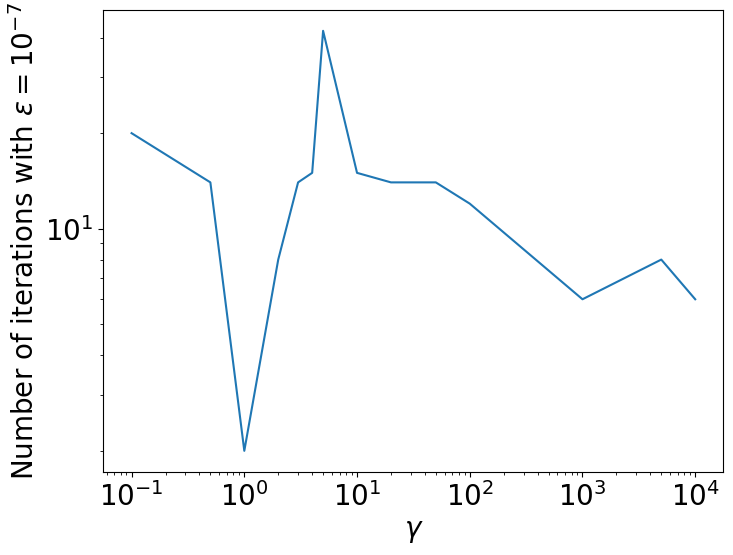

In [28]:
plt.rc("text", usetex=False)

# Смотрим, как число итераций зависит от обусловленности матрицы.
gammas = [0.1, 0.5, 1, 2, 3, 4, 5, 10, 20, 50, 100, 1000, 5000, 10000]
num_iter_converg = []
for g in gammas:
    A = np.array([[1, 0], 
                  [0, g]], dtype=np.float64)
    f = lambda x: my_f(x, A)
    gradf = lambda x: my_gradf(x, A)
    x0 = np.random.rand(A.shape[0])
    gd = fo.GradientDescent(f, gradf, ss.ExactLineSearch4Quad(A))
    x = gd.solve(x0, tol=1e-7, max_iter=300)
    num_iter_converg.append(len(gd.get_convergence()))

plt.figure(figsize=(8, 6))
plt.loglog(gammas, num_iter_converg)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlabel(r"$\gamma$", fontsize=20)
plt.ylabel(r"Number of iterations with $\varepsilon = 10^{-7}$", fontsize=20)
plt.show()

<h2><p id="7">Nesterov accelerated methods (Nesterov, 1983)</p></h2>

\begin{equation*}
\begin{split}
& y_0 = x_0 \\
& x_{k+1} = y_k - \alpha_k f'(y_k)\\
& y_{k+1} = x_{k+1} + \frac{k}{k + 3} (x_{k+1} - x_k)
\end{split}
\end{equation*}


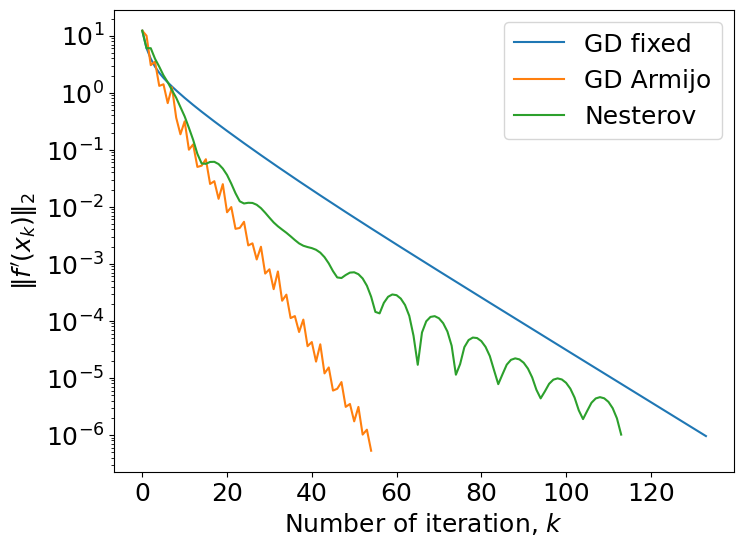

In [29]:
# Строим устойчивую симметричную положительно определенную матрицу.
rng = np.random.default_rng(42)
n = 10
Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
eigvals = np.geomspace(1.0, 10.0, n)
A = Q.T.dot(np.diag(eigvals)).dot(Q)
x_true = rng.standard_normal(n)
b = A.dot(x_true)
f = lambda x: 0.5 * x.dot(A.dot(x)) - b.dot(x)
grad = lambda x: A.dot(x) - b
A_eigvals = np.linalg.eigvalsh(A)
L = np.max(A_eigvals)
mu = np.min(A_eigvals)

# Сравниваем несколько методов на одной и той же задаче.
methods = {
    "GD fixed": fo.GradientDescent(f, grad, ss.ConstantStepSize(1./ L)),
    "GD Armijo": fo.GradientDescent(
        f, grad, ss.Backtracking("Armijo", rho=0.5, beta=0.1, init_alpha=1.0)
    ),
}
x0 = rng.standard_normal(n)
max_iter = 5000
tol = 1e-6
for m in methods:
    _ = methods[m].solve(x0=x0, max_iter=max_iter, tol=tol)


# Добавляем ускоренный метод Нестерова отдельно.
methods["Nesterov"] = fo.AcceleratedGD(f, grad, 
                                       ss.ConstantStepSize(1 / L))
methods["Nesterov"].solve(x0=x0, max_iter=max_iter, tol=tol)

figsize = (8, 6)
fontsize = 18

# График убывания нормы градиента.
plt.figure(figsize=figsize)
for m in methods:
    plt.semilogy([np.linalg.norm(grad(x)) for x in 
                  methods[m].get_convergence()[:3000]], label=m)
plt.legend(fontsize=fontsize, loc="best")
plt.xlabel("Number of iteration, $k$", fontsize=fontsize)
plt.ylabel(r"$\| f'(x_k)\|_2$", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
_ = plt.yticks(fontsize=fontsize)

<h2><p id="8">BFGS</p></h2>

**Задача**

$min_H||H_k-H||$

$H=H^T$

$H_{y_k}=s_k$

**Решение**

$H_{k+1}=(I-p_ks_ky_k^T)H_k(I-p_ky_ks_k^T)+p_ks_ks_k^T$, 

где $p_k=\frac{1}{y_k^Ts_k}$

**Плюсы**
- быстрее градиентного спуска
- хорошо работает на практике для задач, при решении которых возможно хранить матрицу

**Минусы**
- хранит всю матрицу

<h2><p id="9">L-BFGS (BFGS с ограниченной памятью)</p></h2>

- сложность хранения и обновления гессиана $O(n^2)$
- нам нужна не сама матрица, а некая эффективная процедура умножения ее на вектор $f'(x)$
- значения $y$ и $s$ на первых итерациях могут портить оценку $B$ или $H$ на более поздних операциях

**Идея метода:**

Использовать последние $m<<n$ значений $(s,y)$ и корректировать $H_{m,0}$ для каждой итерации. 

Тогда сложность будет $O(mn)$

**L-BFGS**
- еще лучше работает на практике
- нужно заранее определить $m$
- BFGS обновляет $H$ рекурсивно

$H_{k+1}=V_k^TH_kV_k+p_ks_ks_k^T$, $V_k=I-p_ky_ks_k$

$H_{k+1}=V_k^TH_kV_k+p_ks_ks_k^T=V_k^TV_{k-1}^TH_{k-1}V_{k-1}V_k+p_{k-1}V_k^TV_{k-1}^Ts_{k-1}s_{k-1}^TV_{k-1}V_k+p_ks_ks_k^T=V_k^T...V_{k-m+1}^TH_{m,0}V_{k-m+1}...V_k+p_{k-m+1}V_k^T...V_{k-m+2}^Ts_{k-m+1}^TV_{k-m+2}...V_k+...+p_ks_ks_k^T$

- эффективное вычисление $H_kf'(x)$ без явного формирования $H_k$

**Плюсы**
- сложность одной итерации $O(n^2)+...$
- вместо решения систем линейных уравнений используется текущаю информация о функции и градиенте для аналитического вычисления приближения обращённого гессиана
- требуется линейное количество памяти
- сверхлинейная сходимость к решению задачи

**Минусы**
- обощение на стохастический случай НЕ работает
- выбор начального приближения $B_0$ или $H_0$
- нет разработанной теории сходимости и оптимальности

```python
def get_lbfgs_direction(x):
    
    if H is None:
        
        current_grad = grad(x)
        
        return -current_grad
    
    else:
        
        q = current_grad
        
        alpha = np.zeros(len(s_hist))
        
        rho = np.zeros(len(s_hist))
        
        for i in range(len(s_hist) - 1, -1, -1):
            
            rho[i] = 1. / s_hist[i].dot(y_hist[i])
            
            alpha[i] = s_hist[i].dot(q) * rho[i]
            
            q = q - alpha[i] * y_hist[i]
            
        r = q * H
        
        for i in range(len(s_hist)):
            
            beta = rho[i] * y_hist[i].dot(r)
            
            r = r + s_hist[i] * (alpha[i] - beta)
            
    return -r

```

### Задача - Поиск аналитического центра системы неравенств

$$
f(x) = - \sum_{i=1}^m \log(1 - a_i^{\top}x) - \sum\limits_{i = 1}^n \log (1 - x^2_i) \to \min_x
$$

In [30]:
import scipy.optimize as scopt

# Готовим задачу для сравнения L-BFGS и BFGS.
rng = np.random.default_rng(42)
n = 300
m = 100
x0 = np.zeros(n)
max_iter = 100
tol = 1e-5
A = rng.random((m, n)) * 0.01

# log1p делает вычисление устойчивее около нуля.
f = lambda x: -np.sum(np.log1p(-A.dot(x))) - np.sum(np.log1p(-(x * x)))
grad_f = lambda x: np.sum(A.T / (1 - A.dot(x)), axis=1) + 2 * x / (1 - np.power(x, 2))

method = {
    "LBFGS": fo.LBFGS(f, grad_f, hist_size=15),
}

In [31]:
for m in method:
    print("\t Method {}".format(m))
    _ = method[m].solve(x0=x0, tol=tol, max_iter=max_iter, disp=True)

print("\t Method BFGS Scipy")
# Сохраняем точки траектории SciPy для общего графика.
scopt_conv = []
scopt_res = scopt.minimize(f, x0, method="BFGS", jac=grad_f, callback=lambda x: scopt_conv.append(x), 
                           tol=tol, options={"maxiter": max_iter})
print("Result: {}".format(scopt_res.message))
if scopt_res.success:
    print("Convergence in {} iterations".format(scopt_res.nit))
print("Function value = {}".format(f(scopt_res.x)))

	 Method LBFGS
Required tolerance achieved!
Convergence in 6 iterations
Function value = -14.11634930875117
Norm of gradient = 1.72761660813093e-06
	 Method BFGS Scipy
Result: Optimization terminated successfully.
Convergence in 8 iterations
Function value = -14.116349308679006


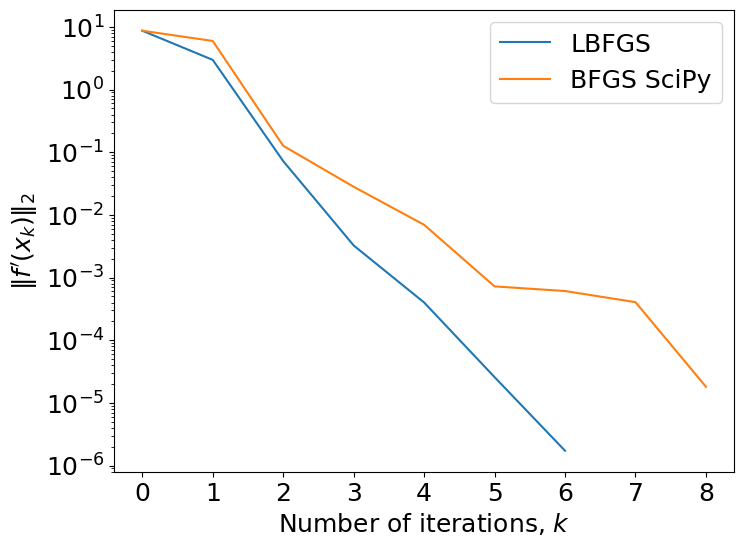

In [32]:
# Сравниваем скорость сходимости по норме градиента.
plt.figure(figsize=(8, 6))

for m in method:
    plt.semilogy([np.linalg.norm(grad_f(x)) for x in method[m].get_convergence()], label=m)

plt.semilogy([np.linalg.norm(grad_f(x)) for x in [x0] + scopt_conv], label="BFGS SciPy")
plt.ylabel(r"$\|f'(x_k)\|_2$", fontsize=18)
plt.xlabel("Number of iterations, $k$", fontsize=18)
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
_ = plt.yticks(fontsize=18)

<h2><p id="10">Применение оптимизационных методов для нейронных сетей</p></h2>

In [33]:
# Проверяем наличие torchvision без повторной установки.
import importlib.util

if importlib.util.find_spec("torchvision") is None:
    print("torchvision не найден. Установите пакет один раз вручную: pip install torchvision")
else:
    print("torchvision уже установлен.")

torchvision уже установлен.


In [34]:
# Импорты для эксперимента с MNIST.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline
from IPython import display

In [35]:
# Простая сверточная сеть для MNIST.
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Один проход обучения по мини-батчам.
def train(model, train_loader, optimizer, epoch, log_interval):
    model.train()
    current_conv = []
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        current_conv.append(loss.item())
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
    return current_conv

# Оценка качества на тестовой выборке.
def test(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item() # sum up batch loss
            pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [36]:
from pathlib import Path

# Фиксируем seed для воспроизводимости примера.
torch.manual_seed(42)
data_root = Path("../data")
transform = transforms.Compose([transforms.ToTensor()])
download_mnist = not (data_root / "MNIST").exists()

train_dataset = datasets.MNIST(data_root, train=True, download=download_mnist, transform=transform)
test_dataset = datasets.MNIST(data_root, train=False, download=download_mnist, transform=transform)

# Ограничиваем выборку, чтобы ноутбук выполнялся быстрее.
train_subset = torch.utils.data.Subset(train_dataset, range(5000))
test_subset = torch.utils.data.Subset(test_dataset, range(1000))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=256, shuffle=False)

In [37]:
# Небольшие значения, чтобы пример выполнялся быстро.
epochs = 1
log_interval = 20
lr = 1e-3
momentum = 0.9

In [38]:
# Для честного сравнения создаем отдельную модель под каждый оптимизатор.
models = {
    "SGD": Net(),
    "SGD momentum": Net(),
    "Adam": Net(),
    "Adagrad": Net()
}

optimizers = {
    "SGD": optim.SGD(models["SGD"].parameters(), lr=lr),
    "SGD momentum": optim.SGD(models["SGD momentum"].parameters(), lr=lr, momentum=momentum),
    "Adam": optim.Adam(models["Adam"].parameters(), lr=lr),
    "Adagrad": optim.Adagrad(models["Adagrad"].parameters(), lr=lr)
}

# Запускаем обучение всех оптимизаторов в одинаковых условиях.
conv = {opt_name: [] for opt_name in optimizers}
for opt in optimizers:
    print(opt)
    for epoch in range(1, epochs + 1):
        cur_conv = train(models[opt], train_loader, optimizers[opt], epoch, log_interval)
        conv[opt] = conv[opt] + cur_conv
        test(models[opt], test_loader)

SGD
Train Epoch: 1 [0/5000 (0%)]	Loss: 2.304926
Train Epoch: 1 [2560/5000 (50%)]	Loss: 2.310366

Test set: Average loss: 2.3123, Accuracy: 73/1000 (7%)

SGD momentum
Train Epoch: 1 [0/5000 (0%)]	Loss: 2.306716
Train Epoch: 1 [2560/5000 (50%)]	Loss: 2.305874

Test set: Average loss: 2.3011, Accuracy: 92/1000 (9%)

Adam
Train Epoch: 1 [0/5000 (0%)]	Loss: 2.306430
Train Epoch: 1 [2560/5000 (50%)]	Loss: 2.198353

Test set: Average loss: 1.6408, Accuracy: 671/1000 (67%)

Adagrad
Train Epoch: 1 [0/5000 (0%)]	Loss: 2.303307
Train Epoch: 1 [2560/5000 (50%)]	Loss: 2.253510

Test set: Average loss: 2.1836, Accuracy: 535/1000 (54%)



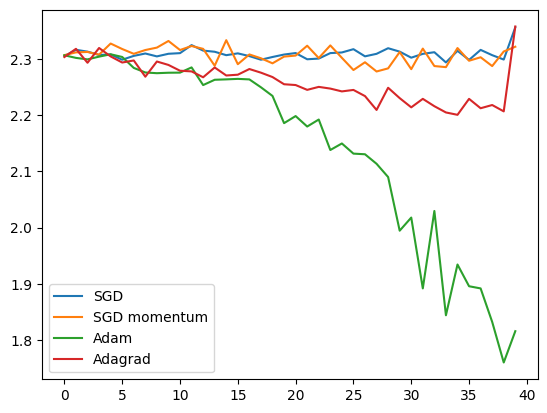

In [39]:
# Визуально сравниваем динамику loss.
for opt_name in conv:
    plt.plot(conv[opt_name], label=opt_name)
plt.legend()